In [ ]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-sfonjqu3
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-sfonjqu3
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done


In [ ]:
import matplotlib.pyplot as plt # plotting
import matplotlib.image as mpimg
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import json
import torch
from collections import Counter
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import clip
from google.colab import drive
import os
from os import listdir
from os.path import isfile, join
drive.mount('/content/gdrive')
os.chdir("/content/gdrive/MyDrive/train")
os.chdir("/content/gdrive/MyDrive/test")
os.chdir("/content/gdrive/MyDrive/val")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
def find_most_common_answer(answers):
    answer_counter = Counter(answers)
    most_common_answers = answer_counter.most_common()
    most_common_answer, count = most_common_answers[0]
    return most_common_answer

def select_most_common_answers(df):
    selected_answers = []
    for idx, row in df.iterrows():
        answers = [answer["answer"] for answer in row["answers"]]
        selected_answer = find_most_common_answer(answers)

        selected_answers.append({"answer": selected_answer
        })

    # Update the "answer" and "answer_confidence" columns in the DataFrame
    df[["answer"]] = pd.DataFrame(selected_answers)

    return df.drop(["answers"], axis=1)

def plot_loss(train_loss, val_loss):
    epochs = range(1, len(train_loss) + 1)

    plt.plot(epochs, train_loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

def plot_img(path):
    # Load the JPEG image
    image = mpimg.imread(path)

    # Plot the image
    plt.imshow(image)
    plt.axis('off')  # Remove axis ticks and labels
    plt.show()

In [ ]:
def dataloader_json(path,test=False):
    # Load the JSON file
    with open(path, 'r') as f:
        data = json.load(f)
    # Create a DataFrame from the loaded JSON data
    df = pd.DataFrame(data)

    if test:
        return df

    return select_most_common_answers(df)

In [ ]:
train_df = dataloader_json("/content/gdrive/MyDrive/train.json")

train_df

,image,question,answer_type,answerable,answer
0,VizWiz_train_00000000.jpg,What's the name of this product?,other,1,basil leaves
1,VizWiz_train_00000001.jpg,Can you tell me what is in this can please?,other,1,coca cola
2,VizWiz_train_00000002.jpg,Is this enchilada sauce or is this tomatoes? ...,other,1,tomatoes
3,VizWiz_train_00000003.jpg,What is the captcha on this screenshot?,other,1,t36m
4,VizWiz_train_00000004.jpg,What is this item?,other,1,solar garden light
...,...,...,...,...,...
20518,VizWiz_train_00023949.jpg,What's the color for this laptop?,other,1,black
20519,VizWiz_train_00023950.jpg,"(inaudible) can you see it? If so, then tell m...",other,1,unanswerable
20520,VizWiz_train_00023951.jpg,What are the three numbers I have to type?,unanswerable,0,unsuitable image
20521,VizWiz_train_00023952.jpg,Is it a box?,yes/no,1,no


In [ ]:
question=train_df['question']

In [ ]:
question_counts = {
    "What": train_df['question'].str.startswith("What").sum(),
    "Why": train_df['question'].str.startswith("Why").sum(),
    "How": train_df['question'].str.startswith("How").sum(),
    "When": train_df['question'].str.startswith("When").sum(),
    "Is": train_df['question'].str.startswith("Is").sum(),
    "Can": train_df['question'].str.startswith("Can").sum(),
    "Where": train_df['question'].str.startswith("Where").sum(),
}


In [ ]:
sunburst_data = pd.DataFrame(question_counts.items(), columns=['Question Type', 'Count'])


In [ ]:
fig = px.sunburst(sunburst_data, path=['Question Type'], values='Count', title="Distribution of Questions Starting with What, Why, How, When, Is, Can, Where")
fig.show()

In [ ]:
from google.colab import files
train_df['question'].to_excel('question.xlsx',index=False)
files.download(r'question.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
train_df['question'].tolist()

["What's the name of this product?",
 'Can you tell me what is in this can please?',
 'Is this enchilada sauce or is this tomatoes?  Thank you.',
 'What is the captcha on this screenshot?',
 'What is this item?',
 "What's this?",
 'What is in this bottle?',
 'This item.',
 'What color do these look?',
 'Surface look clean? Thank you.',
 'Is this.',
 'What is the sodium content of this can of food?',
 'what is this?',
 'What kind of drink is this?',
 'What flavor are these?',
 'What color... what color is this skirt?',
 'How much money is on the table?',
 'What is the name of this product? What is the name of this product?',
 'What is this? ',
 'Can I ask about anything or any information without taking any pictures?',
 'What is this game?',
 'Alright, and what does this label say?',
 'What is in this can?',
 'What is this movie?',
 'Can you see the piece of mail and can you tell me who this mail is for?',
 'What is this a picture of?',
 'What is this?',
 'Am I right when I say that thi

In [ ]:
import nltk
nltk.download('punkt')
import plotly.express as px
def first_six_words(question):
    tokens = nltk.word_tokenize(question.lower())  # Tokenize and convert to lowercase
    return tokens[:6]  # Return the first 6 words

# Apply the function to the entire dataset
first_words_list = [first_six_words(q) for q in question]

# Step 3: Convert the list to a DataFrame for easier manipulation
df = pd.DataFrame(first_words_list, columns=['Word1', 'Word2', 'Word3', 'Word4', 'Word5', 'Word6'])

# Count frequency of word sequences
df['sequence'] = df[['Word1', 'Word2', 'Word3', 'Word4', 'Word5', 'Word6']].agg(' '.join, axis=1)
sequence_count = df['sequence'].value_counts().reset_index()
sequence_count.columns = ['Sequence', 'Frequency']

# Splitting the sequences back into separate words for sunburst plotting
sequence_count[['Word1', 'Word2', 'Word3', 'Word4', 'Word5', 'Word6']] = sequence_count['Sequence'].str.split(' ', expand=True)

# Step 4: Plot the sunburst diagram using Plotly
fig = px.sunburst(
    sequence_count,
    path=['Word1', 'Word2', 'Word3', 'Word4', 'Word5', 'Word6'],  # Hierarchical path representing words
    values='Frequency',  # The frequency of the sequences
    color='Frequency',   # Color by frequency for better visualization
    color_continuous_scale='RdYlBu',  # Optional color scale
    title='Sunburst Diagram: Distribution of First Six Words in VizWiz Questions'
)

# Display the chart
fig.show()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


TypeError: sequence item 5: expected str instance, NoneType found

In [ ]:
train_df['answer'].value_counts()

unanswerable                               3941
unsuitable                                 3038
no                                          567
yes                                         516
white                                       298
                                           ... 
jenny craig florentine breakfast pizzas       1
heads                                         1
sunny paris seasoning                         1
bat                                           1
ipseuri new                                   1
Name: answer, Length: 5630, dtype: int64

In [ ]:
val_df = dataloader_json("/content/val.json")
val_df

,image,question,answer_type,answerable,answer
0,VizWiz_val_00000000.jpg,Ok. There is another picture I hope it is a be...,unanswerable,0,unanswerable
1,VizWiz_val_00000001.jpg,Can you tell me what this medicine is please?,other,1,night time
2,VizWiz_val_00000002.jpg,What is the title of this book?,other,1,dog years
3,VizWiz_val_00000003.jpg,Which one is the blue one?,other,1,right
4,VizWiz_val_00000004.jpg,What does the arrow say?,unanswerable,0,unanswerable
...,...,...,...,...,...
4314,VizWiz_val_00004314.jpg,what is this?,other,1,salad dressing
4315,VizWiz_val_00004315.jpg,Is this modern?,unanswerable,0,unsuitable
4316,VizWiz_val_00004316.jpg,I need to buy this battery for my cordless pho...,unanswerable,0,unanswerable
4317,VizWiz_val_00004317.jpg,What kind of mix is this?,other,1,cake


In [ ]:
val_df['answer'].nunique()

1531

In [ ]:
data_df = pd.concat((train_df,val_df), axis =0,ignore_index=True)
data_df

,image,question,answer_type,answerable,answer
0,VizWiz_train_00000000.jpg,What's the name of this product?,other,1,basil leaves
1,VizWiz_train_00000001.jpg,Can you tell me what is in this can please?,other,1,coca cola
2,VizWiz_train_00000002.jpg,Is this enchilada sauce or is this tomatoes? ...,other,1,tomatoes
3,VizWiz_train_00000003.jpg,What is the captcha on this screenshot?,other,1,t36m
4,VizWiz_train_00000004.jpg,What is this item?,other,1,solar garden light
...,...,...,...,...,...
24837,VizWiz_val_00004314.jpg,what is this?,other,1,salad dressing
24838,VizWiz_val_00004315.jpg,Is this modern?,unanswerable,0,unsuitable
24839,VizWiz_val_00004316.jpg,I need to buy this battery for my cordless pho...,unanswerable,0,unanswerable
24840,VizWiz_val_00004317.jpg,What kind of mix is this?,other,1,cake


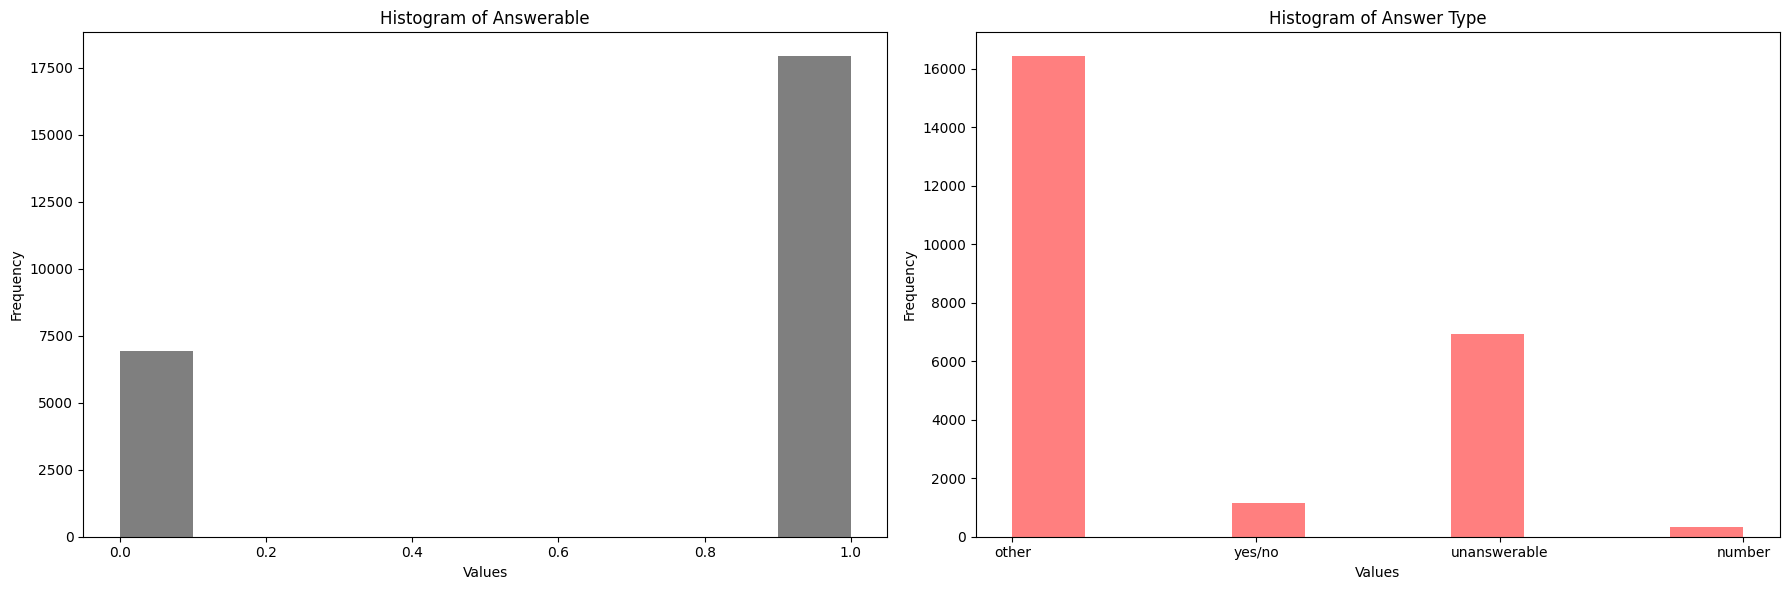

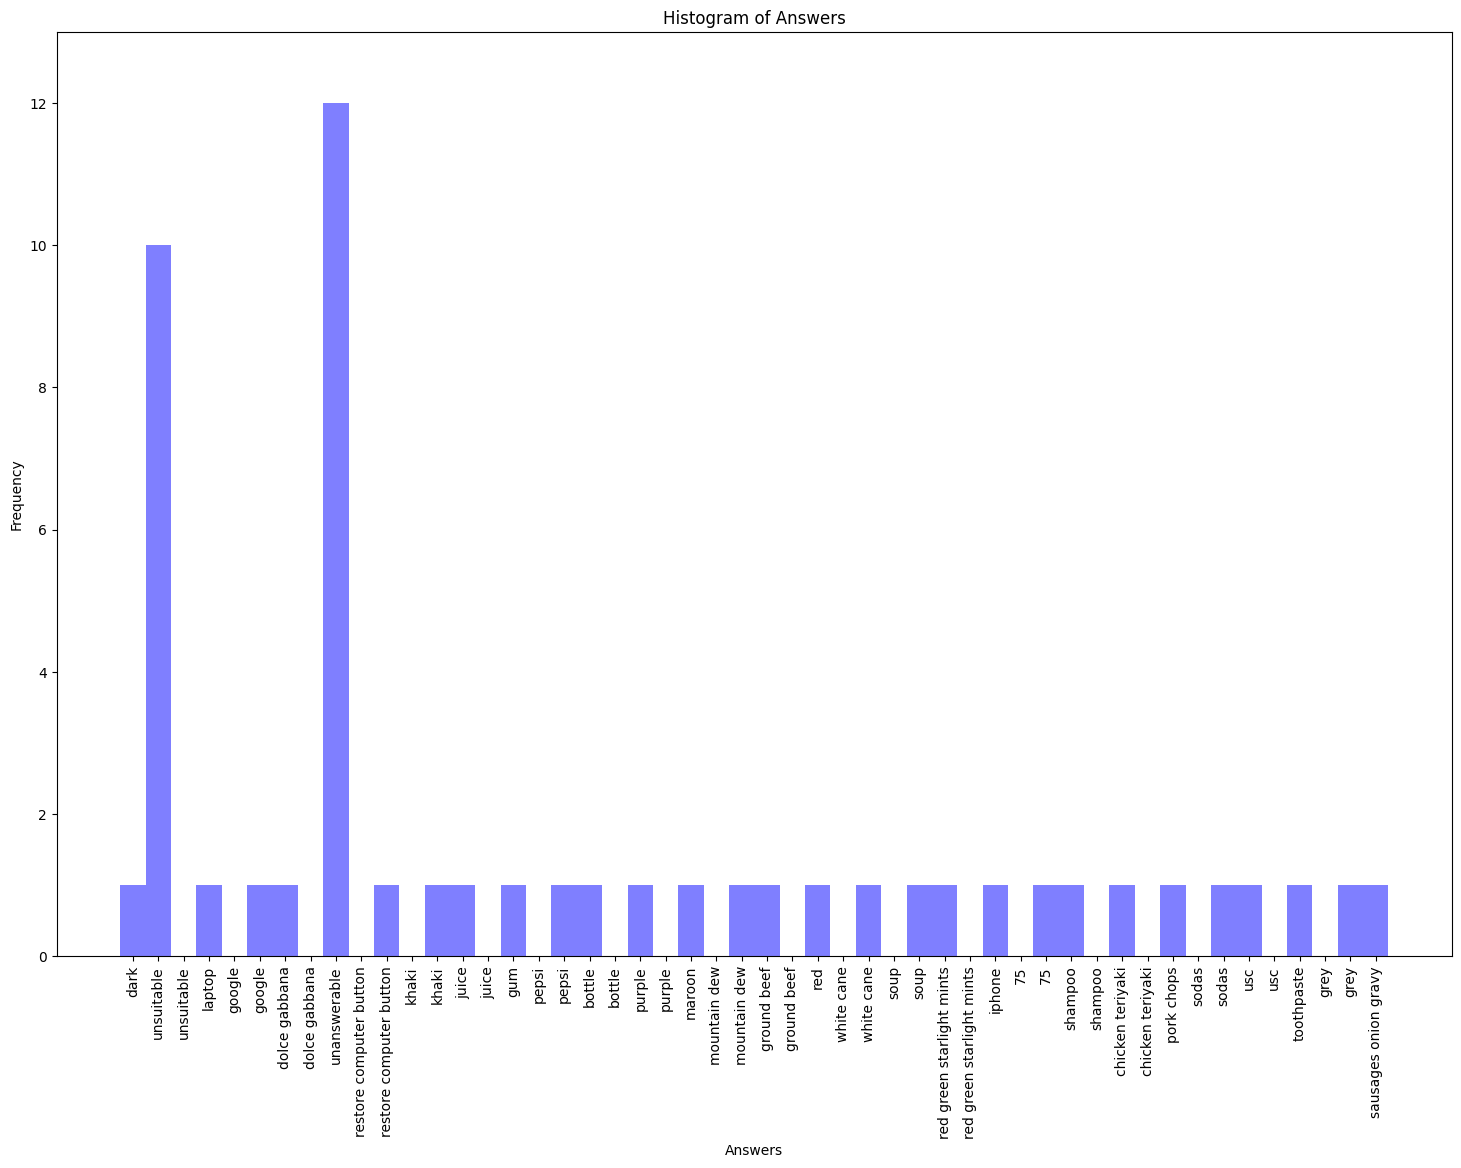

In [ ]:
# Create a figure with six subplots
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(18, 6))

# Plot histogram for 'answerable' with a different color
ax1.hist(pd.concat((train_df,val_df),axis = 0)['answerable'], bins=10, alpha=0.5, color='black', align='mid')
ax1.set_title('Histogram of Answerable')
ax1.set_xlabel('Values')
ax1.set_ylabel('Frequency')

# Plot histogram for 'answer_type' with a different color
ax2.hist(pd.concat((train_df,val_df),axis = 0)['answer_type'], bins=10, alpha=0.5, color='red', align='mid')
ax2.set_title('Histogram of Answer Type')
ax2.set_xlabel('Values')
ax2.set_ylabel('Frequency')

fig.tight_layout()

# Display the plot
plt.show()

# Create the histogram
plt.figure(figsize=(18, 12))  # Adjust the figure size as per your preference
counts, bins, patches = plt.hist(data_df.sample(n=50, random_state=42,replace=False)['answer'], bins=50, color='blue', alpha=0.5)

bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Customize the plot
plt.title('Histogram of Answers')
plt.xlabel('Answers')
plt.ylabel('Frequency')


plt.xticks(rotation=90)

plt.xticks(bin_centers)

max_count = max(counts)
plt.ylim(0, max_count + 1)
# Show the plot
plt.show()

In [ ]:
ans_lb = LabelEncoder()
data_df['answer'] = ans_lb.fit_transform(data_df['answer'])
ans_type_lb = LabelEncoder()
data_df['answer_type']= ans_type_lb.fit_transform(data_df['answer_type'])

In [ ]:
data_df

,image,question,answer_type,answerable,answer
0,VizWiz_train_00000000.jpg,What's the name of this product?,1,1,768
1,VizWiz_train_00000001.jpg,Can you tell me what is in this can please?,1,1,1727
2,VizWiz_train_00000002.jpg,Is this enchilada sauce or is this tomatoes? ...,1,1,5885
3,VizWiz_train_00000003.jpg,What is the captcha on this screenshot?,1,1,5694
4,VizWiz_train_00000004.jpg,What is this item?,1,1,5378
...,...,...,...,...,...
24837,VizWiz_val_00004314.jpg,what is this?,1,1,5058
24838,VizWiz_val_00004315.jpg,Is this modern?,2,0,6042
24839,VizWiz_val_00004316.jpg,I need to buy this battery for my cordless pho...,2,0,6033
24840,VizWiz_val_00004317.jpg,What kind of mix is this?,1,1,1269


In [ ]:
val = data_df.iloc[20523:].reset_index(drop=True)
val

,image,question,answer_type,answerable,answer
0,VizWiz_val_00000000.jpg,Ok. There is another picture I hope it is a be...,2,0,6033
1,VizWiz_val_00000001.jpg,Can you tell me what this medicine is please?,1,1,4135
2,VizWiz_val_00000002.jpg,What is the title of this book?,1,1,2220
3,VizWiz_val_00000003.jpg,Which one is the blue one?,1,1,4962
4,VizWiz_val_00000004.jpg,What does the arrow say?,2,0,6033
...,...,...,...,...,...
4314,VizWiz_val_00004314.jpg,what is this?,1,1,5058
4315,VizWiz_val_00004315.jpg,Is this modern?,2,0,6042
4316,VizWiz_val_00004316.jpg,I need to buy this battery for my cordless pho...,2,0,6033
4317,VizWiz_val_00004317.jpg,What kind of mix is this?,1,1,1269


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_clip, preprocess = clip.load("ViT-L/14", device=device)

print(f'Using {device}')

Using cpu


In [ ]:
encodings = []
for img , question in tqdm(zip(train_df['image'],train_df['question'])):
    if "train" in img:

        image = preprocess(Image.open(f'/content/gdrive/MyDrive/train/train/{img}').rotate(90)).unsqueeze(0).to(device)
    elif "test" in img:
       image = preprocess(Image.open(f'/content/gdrive/MyDrive/test/test/{img}')).unsqueeze(0).to(device)
    else:
        image = preprocess(Image.open(f'/content/gdrive/MyDrive/val/val/{img}')).unsqueeze(0).to(device)

    text = clip.tokenize(question).to(device)

    with torch.no_grad():
        image_encoding = model_clip.encode_image(image)
        text_encoding = model_clip.encode_text(text)

    encodings.append(torch.cat([image_encoding, text_encoding], dim=-1))


2650it [1:57:58,  2.67s/it]
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-49-96b9d32ae6ed>", line 5, in <cell line: 2>
    image = preprocess(Image.open(f'/content/gdrive/MyDrive/train/train/{img}').rotate(90)).unsqueeze(0).to(device)
  File "/usr/local/lib/python3.10/dist-packages/PIL/Image.py", line 3227, in open
    fp = builtins.open(filename, "rb")
FileNotFoundError: [Errno 2] No such file or directory: '/content/gdrive/MyDrive/train/train/VizWiz_train_00002650.jpg'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py", line 2099, in showtraceback
    stb = value._render_traceback_()
AttributeError: 'FileNotFoundError' object has no attribute '_render_traceback_'

During handling of the above exception, anoth